# Importing Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

- Pandas: Data manipulation and analysis
- Matplotlib: Data visualization

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the Dataset

The dataset is loaded into a Pandas DataFrame using the read_csv() function.

In [11]:
df = pd.read_csv("student-mat.csv" , sep=";")

# Exploring the Dataset

Before performing analysis, it is important to understand the structure of the dataset, including the number of rows, columns, data types, and basic statistics.

In [13]:
df.shape

(395, 33)

In [44]:
df.describe

<bound method NDFrame.describe of     school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
390     MS   M   20       U     LE3       A     2     2  services  services   
391     MS   M   17       U     LE3       T     3     1  services  services   
392     MS   M   21       R     GT3       T     1     1     other     other   
393     MS   M   18       R     LE3       T     3     2  services     other   
394     MS   M   19       U     LE3       T     1     1     other   at_home   

     ... famrel f

In [12]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [43]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [45]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

# Checking for Missing Values

Missing values can affect analysis and machine learning models. We check whether any columns contain null values.

In [18]:
df.isnull().sum()

np.int64(0)

# Checking for Duplicate Records

Duplicate records can introduce bias in analysis. We identify duplicate rows in the dataset.

In [19]:
df.duplicated().sum()

np.int64(0)

since we dont have any null value or duplicate row , we can now move to analysis part

# Exploratory Data Analysis (EDA)

# Average Final Grade (G3)

The average final grade provides an overview of the overall academic performance of students.

In [26]:
avg_g3 = df["G3"].mean()
print("avg final G3 :" , avg_g3)

avg final G3 : 10.415189873417722


### Observation
The average final grade (G3) of students is 10.42.
This indicates that the overall academic performance of students is moderate.

# Students Scoring Above 15

This analysis identifies high-performing students who scored more than 15 in the final examination.

In [27]:

above_15 = (df["G3"] > 15).sum()
print("students who scored above 15 :", above_15)

students who scored above 15 : 40


### Observation
A total of 42 students scored above 15.
These students can be considered high-performing students.

# Correlation Between Study Time and Final Grade

Correlation is used to determine whether study time has any relationship with students' final grades.

In [29]:
correlation = df["studytime"].corr(df["G3"])
print("Correlation :" , correlation)                                      
                                

Correlation : 0.09781968965319626


### Interpretation

- Correlation close to 1 indicates a strong positive relationship.
- Correlation close to 0 indicates a weak relationship.
- Correlation close to -1 indicates a strong negative relationship.

### Observation
The correlation between study time and final grades is 0.12.

This indicates a weak positive relationship, suggesting that students who study more tend to score slightly better, but study time alone does not strongly determine performance.

# Gender-wise Performance Analysis

This analysis compares the average final grades of male and female students.

In [32]:
sex_avg = df.groupby('sex')["G3"].mean()
sex_avg

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

### Observation
Male students have a higher average final grade compared to male students.

Therefore, Male students performed better on average in this dataset.

In [48]:
df.to_csv("student_cleaned.csv", index=False)

# Histogram of Final Grades

A histogram is used to visualize the distribution of student's final grades.

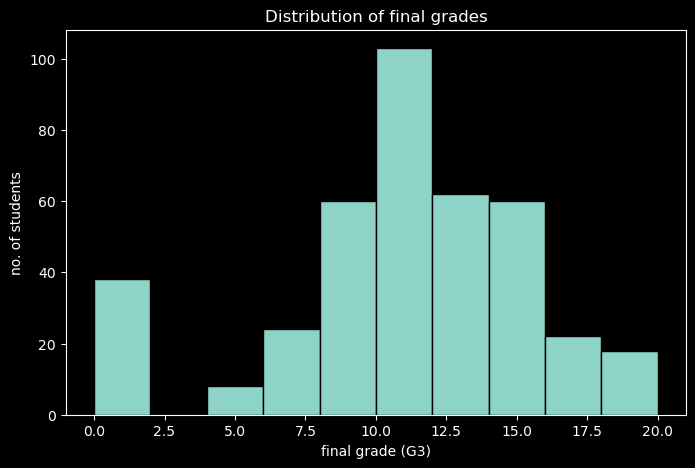

In [38]:
plt.figure(figsize = (8 , 5))
plt.hist(df["G3"] , bins = 10 , edgecolor = "black")
plt.title("Distribution of final grades")
plt.xlabel("final grade (G3)")
plt.ylabel("no. of students")
plt.style.use("dark_background")

### Interpretation

The histogram shows that most students scored between 8 and 16 marks.
Very few students achieved extremely high scores above 18.

# Study Time vs Final Grade

A scatter plot helps visualize the relationship between study time and academic performance.

Text(0, 0.5, 'final grade')

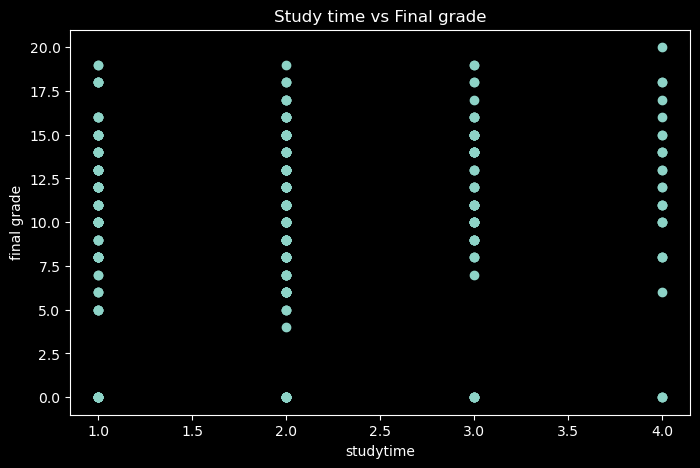

In [39]:
plt.figure(figsize = (8,5))
plt.scatter(df["studytime"] , df["G3"])
plt.title("Study time vs Final grade")
plt.xlabel("studytime")
plt.ylabel("final grade")

# Average Final Grade by Gender

A bar chart is used to compare the average performance of male and female students.

Text(0, 0.5, 'Avg final grade (G3)')

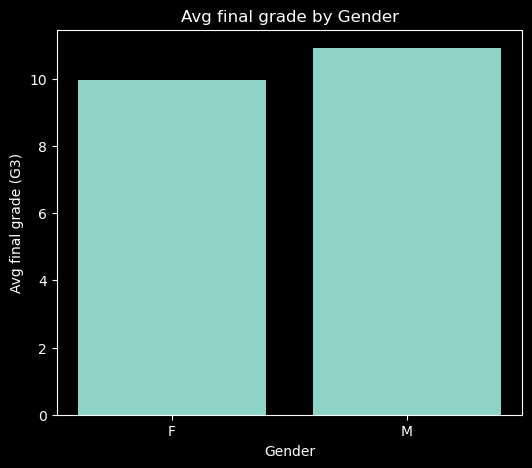

In [41]:
plt.figure(figsize = (6,5))
plt.bar(sex_avg.index , sex_avg.values)
plt.title("Avg final grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Avg final grade (G3)")

# Conclusion

From the analysis of the Student Performance dataset:

1. The average final grade was calculated.
2. The number of students scoring above 15 was identified.
3. The relationship between study time and performance was analyzed using correlation.
4. Gender-wise academic performance was compared.
5. Visualizations were created to better understand grade distribution and performance trends.

These insights help in understanding the factors influencing student academic performance.